# Exploratory Data Analysis (EDA)

## Objective

* This notebook explores the cleaned NHANES dataset before moving on to model development
* It looks at the structure of the dataset, how the variables are distributed, whether any values are missing, how predictors correlate with each other, and how they relate to depression

## Import Libraries and Load Data 

In [1]:
# import the packages needed for eda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display all columns when viewing the dataframe
pd.set_option("display.max_columns", None)

# set a consistent appearance for the visualizations
sns.set_theme(style="whitegrid")

# load the cleaned NHANES dataset
df = pd.read_csv("Nhanes_RawData/Nhanes_Cleaned.csv")

## Basic Overview of the Dataset

In [2]:
# display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (13731, 28)


In [3]:
# display first 5 rows 
display(df.head())

,SEQN,CYCLE,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDEDUC2,DMDMARTZ,INDFMPIR,ALQ111,ALQ121,ALQ130,ALQ142,ALQ151,ALQ170,HSQ590,INDFMMPI,INDFMMPC,PAD680,SLD012,SLD013,SMQ020,SMAQUEX2,WTMEC_COMB,PHQ9_Score,Depression_Flag
0,109266.0,2017-Mar2020,2.0,29.0,5.0,6.0,2.0,2.0,5.0,3.0,5.00,1.0,10.0,1.0,0.0,2.0,0.0,2.0,5.00,3.0,480.0,7.5,8.0,2.0,1.0,5018.441965,0.0,0
1,109271.0,2017-Mar2020,1.0,49.0,3.0,3.0,2.0,1.0,2.0,3.0,2.49,1.0,0.0,2.0,-1.0,1.0,0.0,2.0,1.20,1.0,60.0,10.0,13.0,1.0,1.0,5328.450999,5.0,0
2,109273.0,2017-Mar2020,1.0,36.0,3.0,3.0,2.0,1.0,4.0,3.0,0.83,1.0,0.0,2.0,-1.0,2.0,0.0,1.0,0.53,1.0,180.0,6.5,8.0,1.0,1.0,13639.136523,15.0,1
3,109274.0,2017-Mar2020,1.0,68.0,5.0,7.0,1.0,1.0,4.0,3.0,1.20,1.0,4.0,2.0,5.0,2.0,0.0,2.0,1.20,1.0,300.0,9.5,9.5,2.0,1.0,4800.984750,0.0,0
4,109282.0,2017-Mar2020,1.0,76.0,3.0,3.0,2.0,1.0,5.0,1.0,3.61,1.0,0.0,2.0,-1.0,2.0,0.0,2.0,3.18,3.0,900.0,7.0,8.0,1.0,1.0,19579.290154,5.0,0


In [4]:
# display last 5 rows 
display(df.tail())

,SEQN,CYCLE,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDEDUC2,DMDMARTZ,INDFMPIR,ALQ111,ALQ121,ALQ130,ALQ142,ALQ151,ALQ170,HSQ590,INDFMMPI,INDFMMPC,PAD680,SLD012,SLD013,SMQ020,SMAQUEX2,WTMEC_COMB,PHQ9_Score,Depression_Flag
13726,142303.0,2021-2023,2.0,69.0,5.0,7.0,2.0,1.0,3.0,2.0,0.98,2.0,-1.0,2.0,-1.0,-1.0,0.0,2.0,1.25,1.0,360.0,8.0,10.0,1.0,1.0,18110.606192,0.0,0
13727,142307.0,2021-2023,2.0,49.0,4.0,4.0,2.0,1.0,5.0,3.0,2.49,1.0,10.0,1.0,0.0,2.0,0.0,1.0,2.22,2.0,480.0,7.0,7.0,1.0,1.0,24985.511139,0.0,0
13728,142308.0,2021-2023,1.0,50.0,2.0,2.0,1.0,2.0,4.0,1.0,1.95,1.0,8.0,2.0,0.0,2.0,0.0,2.0,2.50,3.0,600.0,9.0,8.0,2.0,1.0,17064.436205,0.0,0
13729,142309.0,2021-2023,1.0,40.0,2.0,2.0,1.0,1.0,4.0,2.0,3.11,2.0,-1.0,2.0,-1.0,-1.0,0.0,1.0,3.26,3.0,240.0,8.0,12.0,2.0,1.0,17788.216096,0.0,0
13730,142310.0,2021-2023,2.0,80.0,3.0,3.0,1.0,1.0,3.0,1.0,5.00,1.0,3.0,3.0,3.0,2.0,2.0,2.0,4.59,3.0,360.0,9.0,9.0,1.0,1.0,19095.086718,1.0,0


**The cleaned NHANES dataset loaded successfully and contains the observations and variables used throughout the project. Checking the shape and a few sample records gives a quick sense of the data structure and confirms everything loaded correctly.**

## Column Information

In [5]:
print("Columns in the dataset:\n")

for col in df.columns:
    print(col)

Columns in the dataset:

SEQN
CYCLE
RIAGENDR
RIDAGEYR
RIDRETH1
RIDRETH3
RIDEXMON
DMDBORN4
DMDEDUC2
DMDMARTZ
INDFMPIR
ALQ111
ALQ121
ALQ130
ALQ142
ALQ151
ALQ170
HSQ590
INDFMMPI
INDFMMPC
PAD680
SLD012
SLD013
SMQ020
SMAQUEX2
WTMEC_COMB
PHQ9_Score
Depression_Flag


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13731 entries, 0 to 13730
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEQN             13731 non-null  float64
 1   CYCLE            13731 non-null  str    
 2   RIAGENDR         13731 non-null  float64
 3   RIDAGEYR         13731 non-null  float64
 4   RIDRETH1         13731 non-null  float64
 5   RIDRETH3         13731 non-null  float64
 6   RIDEXMON         13731 non-null  float64
 7   DMDBORN4         13731 non-null  float64
 8   DMDEDUC2         13731 non-null  float64
 9   DMDMARTZ         13731 non-null  float64
 10  INDFMPIR         13731 non-null  float64
 11  ALQ111           13731 non-null  float64
 12  ALQ121           13731 non-null  float64
 13  ALQ130           13731 non-null  float64
 14  ALQ142           13731 non-null  float64
 15  ALQ151           13731 non-null  float64
 16  ALQ170           13731 non-null  float64
 17  HSQ590           13731 

In [7]:
# missing values 
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Series([], dtype: int64)

* No missing values show up in the cleaned dataset, which confirms that the data wrangling process handled missing observations before this analysis started.

In [8]:
# duplicate rows 
print(df.duplicated().sum())

0


* No duplicate rows turn up in the cleaned dataset, so each observation represents a unique participant.

**The dataset contains demographic, lifestyle, health, and questionnaire variables, along with the target variable ('Depression_Flag') and the calculated 'PHQ9_Score'. Reviewing the column names and data types helps identify which variables are numeric versus categorical, which matters for how they get handled later in the analysis.**

## Summary Statistics 

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SEQN,13731.0,124764.549487,10251.248292,109266.000000,115828.000000,122295.000000,134815.000000,142310.000000
RIAGENDR,13731.0,1.522395,0.499516,1.000000,1.000000,2.000000,2.000000,2.000000
RIDAGEYR,13731.0,50.389848,18.325570,18.000000,34.000000,52.000000,65.000000,80.000000
RIDRETH1,13731.0,3.190882,1.108226,1.000000,3.000000,3.000000,4.000000,5.000000
RIDRETH3,13731.0,3.388974,1.488864,1.000000,3.000000,3.000000,4.000000,7.000000
RIDEXMON,13731.0,1.497196,0.500010,1.000000,1.000000,1.000000,2.000000,2.000000
DMDBORN4,13731.0,1.233486,0.425639,-1.000000,1.000000,1.000000,1.000000,2.000000
DMDEDUC2,13731.0,3.499017,1.500394,-1.000000,3.000000,4.000000,5.000000,5.000000
DMDMARTZ,13731.0,1.512199,0.955633,-1.000000,1.000000,1.000000,2.000000,3.000000
INDFMPIR,13731.0,2.718949,1.546974,0.000000,1.440000,2.490000,4.200000,5.000000


**The summary statistics give an overview of the numerical variables, including their central tendency, spread, and range. This helps flag variables with large variation, potential outliers, or unusual values that could affect the machine learning models.**

## Target Variable Analysis

**The target variable ('Depression_Flag') shows whether a participant is classified as likely experiencing depression based on their PHQ-9 assessment. Understanding the class distribution matters because a heavily imbalanced target can affect model performance and should influence the choice of evaluation metrics.**

In [10]:
# examin the distribution of the target variable
target_counts = df["Depression_Flag"].value_counts()

print(target_counts)

print("\nPercentage Distribution")
print((target_counts / len(df) * 100).round(2))

Depression_Flag
0    12241
1     1490
Name: count, dtype: int64

Percentage Distribution
Depression_Flag
0    89.15
1    10.85
Name: count, dtype: float64


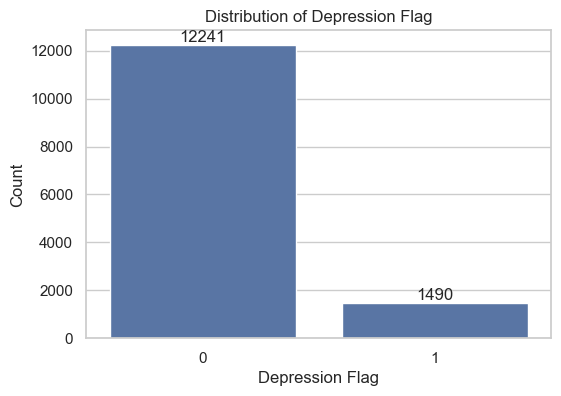

In [11]:
# countplot 
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Depression_Flag"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Depression Flag")
plt.xlabel("Depression Flag")
plt.ylabel("Count")

plt.show()

## Distribution of PHQ-9 Scores

**Before looking at the individual predictors, we first look at the raw PHQ-9 score itself, since 'Depression_Flag' comes directly from it. This helps us understand whether the flag threshold behaves reasonably and shows how depression severity is spread across the sample, not just the binary outcome.**

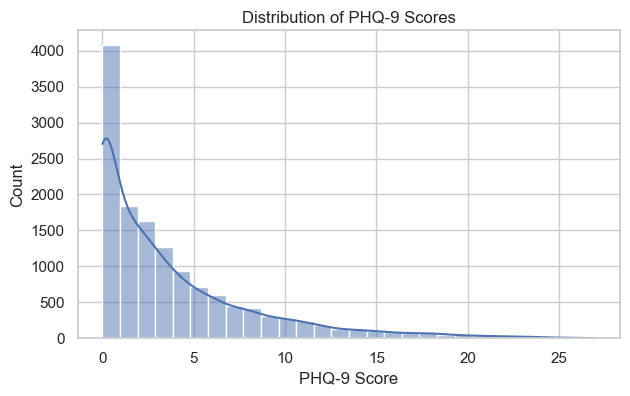

Skewness: 1.79
Percent of respondents scoring 0: 29.72


In [12]:
# histogram of the raw PHQ-9 score
plt.figure(figsize=(7,4))

sns.histplot(df["PHQ9_Score"], bins=28, kde=True)

plt.title("Distribution of PHQ-9 Scores")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Count")

plt.show()

# quantify the shape of the distribution
print("Skewness:", round(df["PHQ9_Score"].skew(), 2))
print("Percent of respondents scoring 0:", round((df["PHQ9_Score"] == 0).mean() * 100, 2))

**Looking at the distribution, the PHQ-9 score is right-skewed (skewness ≈ 1.79), with about 30% of respondents scoring 0 and a median of 2. Most of the sample clusters at the low end of the scale, with a long tail extending toward the maximum possible score of 27. This lines up with the 89/11 class split we saw in 'Depression_Flag' and confirms that most participants in this sample report few or no depressive symptoms.**

## Continuous Variable Distributions

**Several columns in this dataset are numeric codes for categories rather than true continuous measurements, so they should not be summarized or visualized the same way. Based on the data dictionary used during data wrangling, the true continuous/numeric variables are age, the two income-to-poverty ratio measures, average alcohol drinks per occasion, binge drinking days, sedentary time, and weekday/weekend sleep hours. Visualizing these separately shows how they're spread and skewed, which matters before any scaling or transformation is considered.**

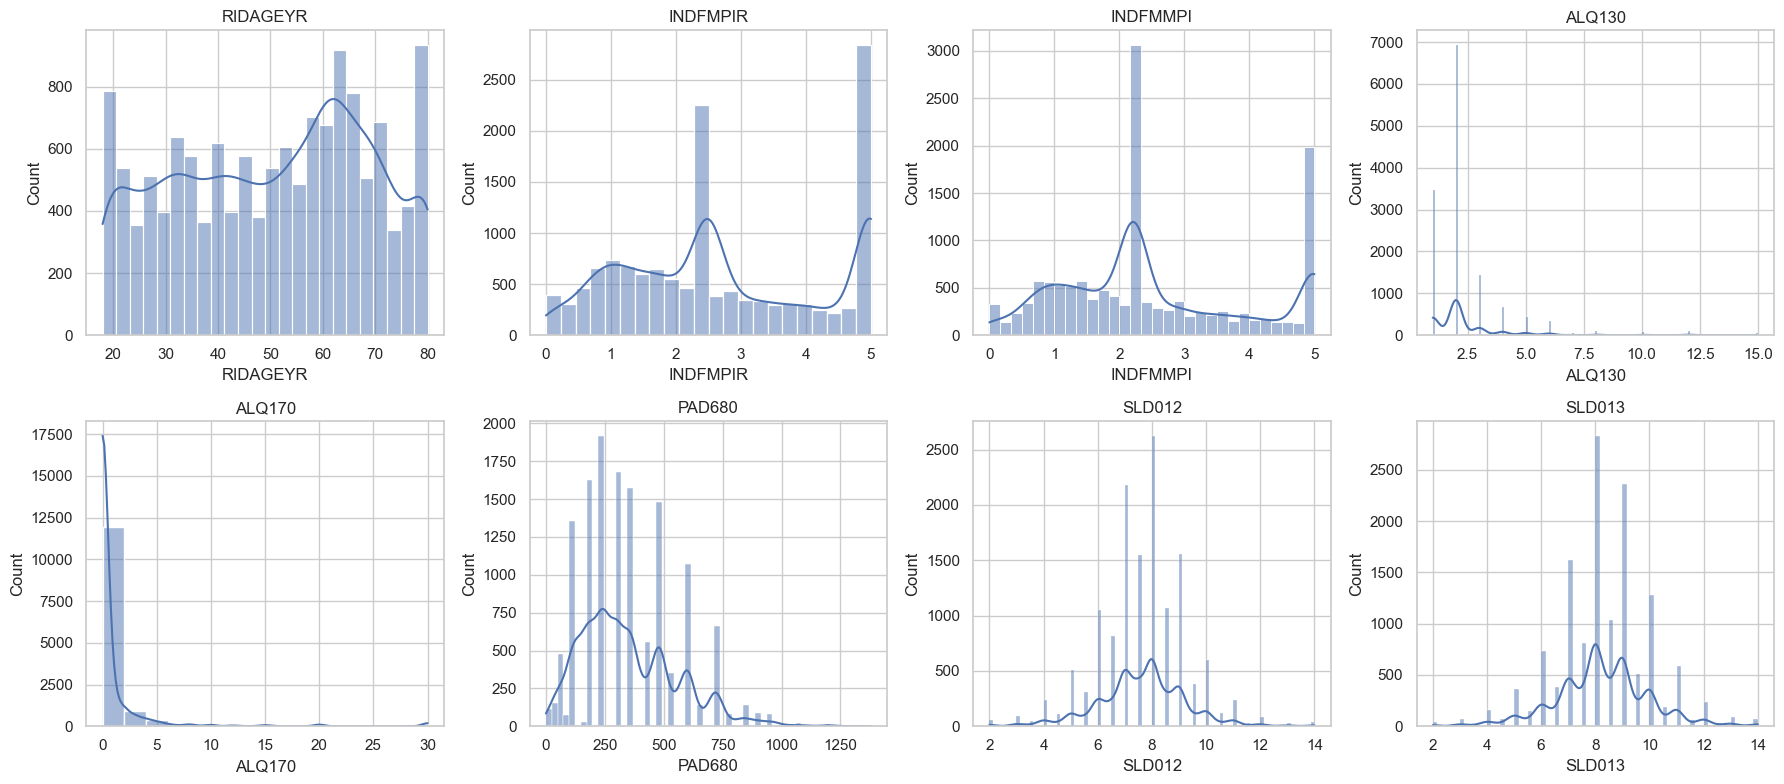

RIDAGEYR   -0.142593
SLD012     -0.048367
SLD013     -0.046201
INDFMPIR    0.185744
INDFMMPI    0.465629
PAD680      0.839357
ALQ130      3.326342
ALQ170      6.433478
dtype: float64

In [13]:
# true continuous / numeric variables (categorical codes are excluded here)
continuous_cols = ["RIDAGEYR", "INDFMPIR", "INDFMMPI", "ALQ130", "ALQ170", "PAD680", "SLD012", "SLD013"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# skewness of each continuous variable
df[continuous_cols].skew().sort_values()

**Looking at the skew values, age and both sleep-hour variables are close to symmetric (skewness roughly -0.14 to -0.05). The two income-to-poverty ratio measures are only mildly right-skewed (0.19 and 0.47), and sedentary time is moderately right-skewed (0.84). Average drinks per occasion and binge-drinking days are the most heavily right-skewed variables (3.33 and 6.43), which reflects most respondents reporting low values with a smaller group of heavier drinkers extending the tail. This skew matters for the modeling stage, since some algorithms are sensitive to feature scale.**

## Categorical Variable Distributions

**The remaining non-continuous columns are demographic, lifestyle, and questionnaire variables stored as numeric codes (for example, gender or education level). Plotting the count of each category helps us see whether categories are reasonably balanced or whether some are rare, which matters for how these variables get encoded later.**

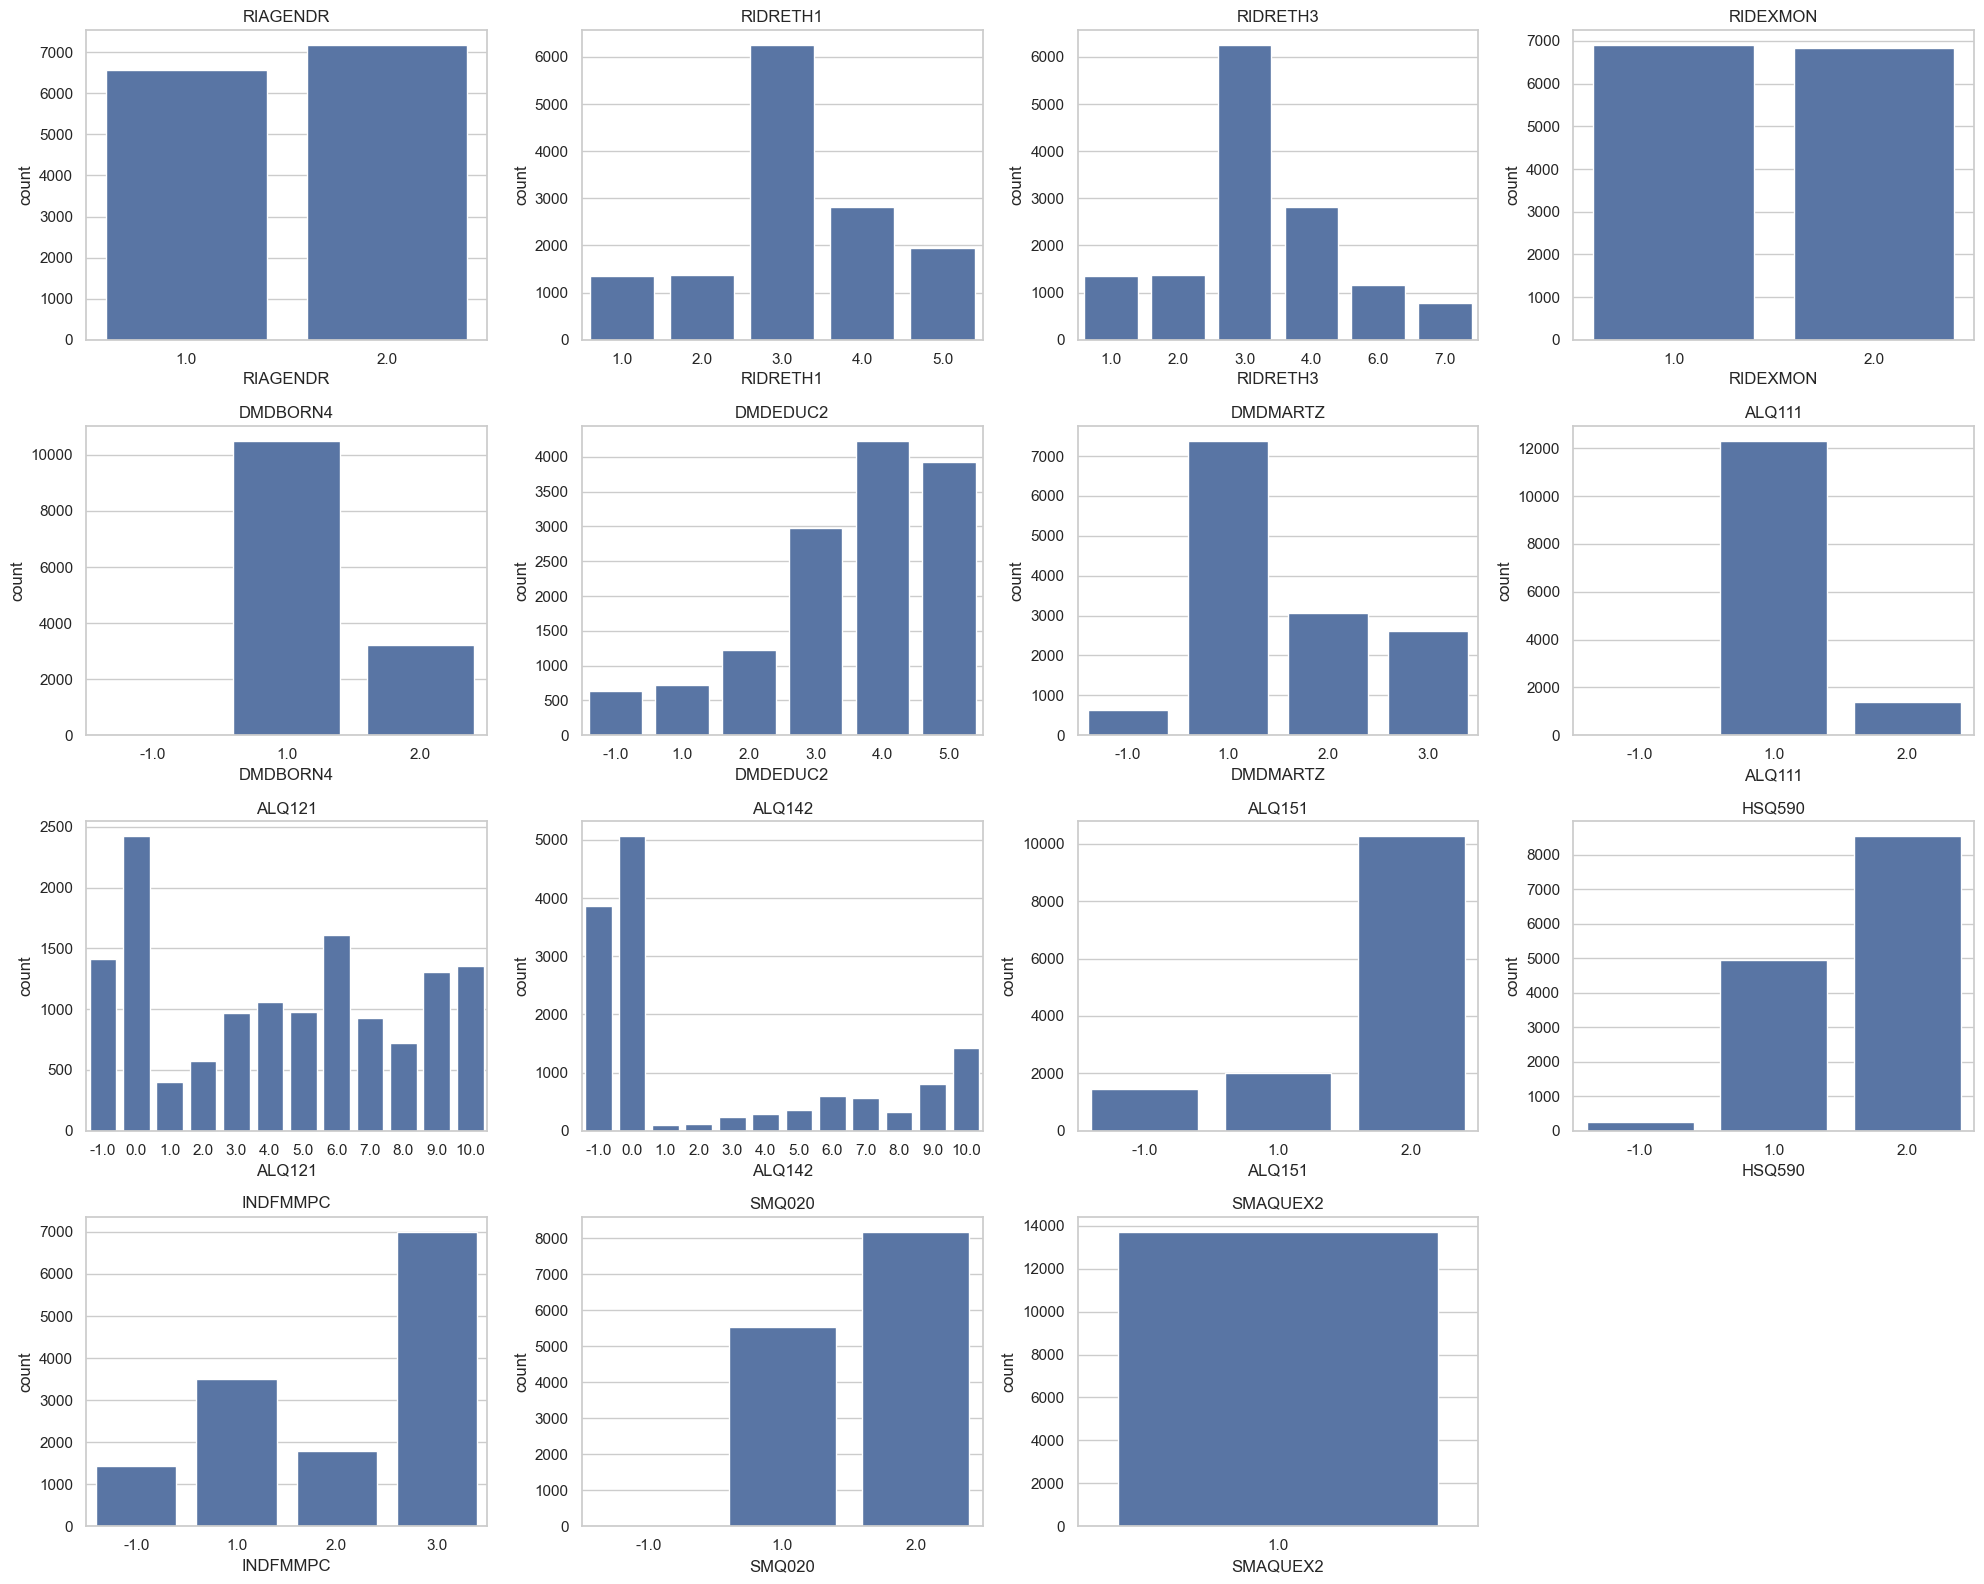

In [14]:
# categorical / coded variables
categorical_cols = ["RIAGENDR", "RIDRETH1", "RIDRETH3", "RIDEXMON", "DMDBORN4",
                     "DMDEDUC2", "DMDMARTZ", "ALQ111", "ALQ121", "ALQ142",
                     "ALQ151", "HSQ590", "INDFMMPC", "SMQ020", "SMAQUEX2"]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)

# hide the unused subplot (15 variables in a 4x4 grid)
for ax in axes[len(categorical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Looking at the category counts, gender is close to balanced (52.2% female, 47.8% male), and Non-Hispanic White is the largest race/ethnicity group at 45.5% of the sample. 'SMAQUEX2' shows only a single bar, which we look at further in the low-variance section below. Several categorical columns also show a bar at -1 (for example 'DMDEDUC2', 'DMDMARTZ', and the alcohol-related questions). The next section checks whether these values represent missing data or an intentional category created during data wrangling.**

### Checking the -1 Code in Categorical Variables

**The summary statistics table earlier showed -1 as the minimum value for several categorical columns, even though 'df.isnull().sum()' reported zero missing values. Before treating -1 as missing data, we wanted to check where this code actually comes from. In the data wrangling notebook, the true NHANES "Refused"/"Don't know" codes (7, 9, 77, 99, etc.) were already converted to NaN using the codebook, and any NaN remaining afterward in a categorical column was deliberately filled with -1 to represent "not answered." This tells us -1 is not unhandled missing data - it was intentionally created as its own category, so it should stay in the analysis rather than being removed or imputed.**

In [15]:
# how often does the -1 ("not answered") code appear in each categorical column?
neg_one_counts = (df[categorical_cols] == -1).sum()
neg_one_pct = (neg_one_counts / len(df) * 100).round(2)

pd.DataFrame({"count": neg_one_counts, "percent": neg_one_pct}).sort_values("percent", ascending=False)

,count,percent
ALQ142,3870,28.18
INDFMMPC,1441,10.49
ALQ151,1439,10.48
ALQ121,1414,10.30
DMDMARTZ,644,4.69
DMDEDUC2,641,4.67
HSQ590,246,1.79
ALQ111,27,0.20
SMQ020,12,0.09
DMDBORN4,5,0.04


**Looking at the "not answered" rate by column, it varies a lot. 'ALQ142' has by far the highest share at 28.18%, followed by 'INDFMMPC' (10.49%), 'ALQ151' (10.48%), and 'ALQ121' (10.30%). 'DMDEDUC2' and 'DMDMARTZ' sit around 4.7%, 'HSQ590' is 1.79%, and 'ALQ111', 'SMQ020', and 'DMDBORN4' are all under 0.2%. 'RIAGENDR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', and 'SMAQUEX2' have no -1 values at all. Since these values were intentionally created during preprocessing to represent "not answered" responses, they'll stay in as their own category instead of being treated as missing data or dropped. Whether they help the model distinguish between classes is something to explore further during feature engineering.**

## Relationships Between Key Predictors and Depression_Flag

**With the individual variable distributions understood, the next step is to look at how a few conceptually relevant predictors relate to the target itself. Age, gender, education, and household income relative to the poverty line are commonly linked to depression in public health research, so we look at these first rather than every predictor at once.**

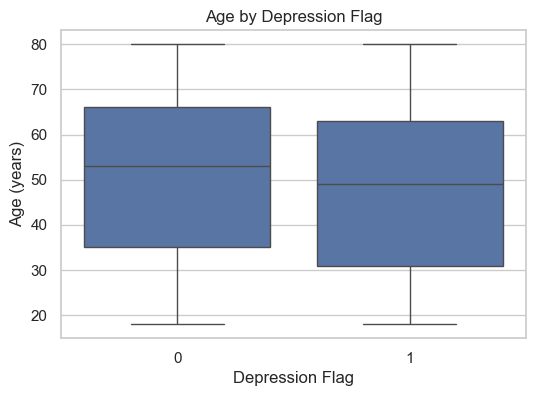

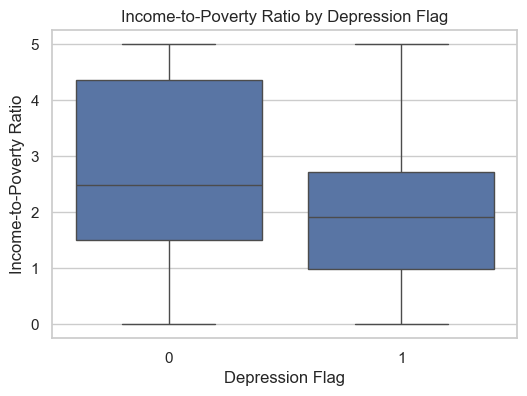

Depression rate by gender (%):
RIAGENDR
1.0     8.46
2.0    13.03
Name: Depression_Flag, dtype: float64

Depression rate by education level (%):
DMDEDUC2
1.0    14.86
2.0    14.19
3.0    12.30
4.0    11.76
5.0     6.11
Name: Depression_Flag, dtype: float64


In [16]:
# age by depression flag
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Depression_Flag", y="RIDAGEYR")

plt.title("Age by Depression Flag")
plt.xlabel("Depression Flag")
plt.ylabel("Age (years)")

plt.show()

# income-to-poverty ratio by depression flag
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Depression_Flag", y="INDFMPIR")

plt.title("Income-to-Poverty Ratio by Depression Flag")
plt.xlabel("Depression Flag")
plt.ylabel("Income-to-Poverty Ratio")

plt.show()

# depression rate by gender (1 = Male, 2 = Female)
print("Depression rate by gender (%):")
print((df.groupby("RIAGENDR")["Depression_Flag"].mean() * 100).round(2))

# depression rate by education level (excluding the -1 "not answered" code)
print("\nDepression rate by education level (%):")
educ = df[df["DMDEDUC2"] != -1]
print((educ.groupby("DMDEDUC2")["Depression_Flag"].mean() * 100).round(2))

**Looking at these relationships, respondents flagged as depressed are slightly younger on average (mean age 47.6) than those who are not (mean age 50.7), though the boxplots show a lot of overlap between the two groups. The income-to-poverty ratio is lower on average among respondents flagged as depressed (mean 2.13) compared to those who are not (mean 2.79). The depression rate is also noticeably higher for females (13.03%) than males (8.46%), and decreases fairly steadily as education increases, from 14.86% at "less than 9th grade" down to 6.11% for college graduates. None of these differences are extreme, which makes sense since depression is a multifactorial outcome, but gender, education, and income-to-poverty ratio all show a clearer relationship with the target than age does.**

## Correlation Analysis

**Correlation is only meaningful for variables measured on a real numeric scale, so this analysis is limited to the continuous variables identified earlier plus 'PHQ9_Score'. This helps us check for multicollinearity among the continuous predictors themselves, as well as see which of them are most closely related to PHQ-9 severity.**

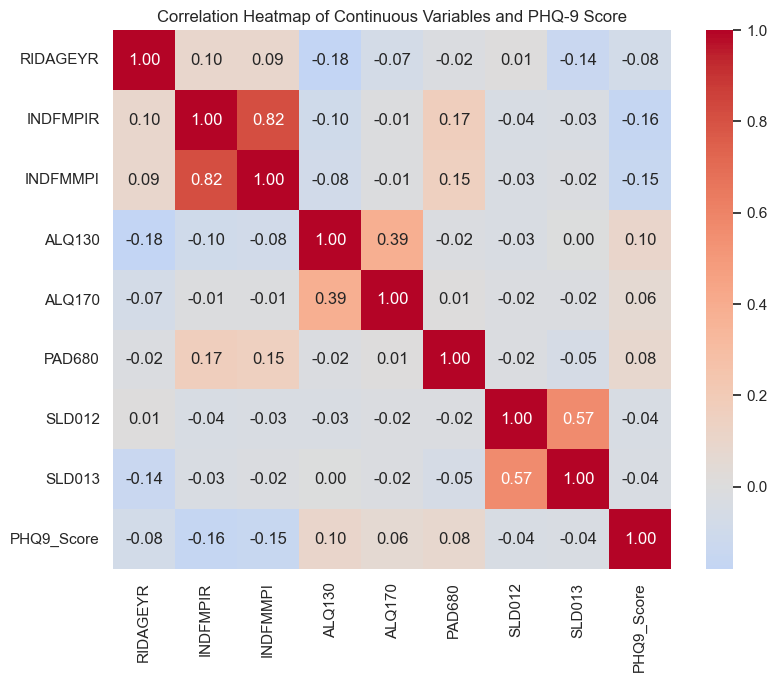

In [17]:
# correlation heatmap for continuous variables and PHQ-9 score
corr_cols = continuous_cols + ["PHQ9_Score"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9,7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Correlation Heatmap of Continuous Variables and PHQ-9 Score")
plt.show()

**Looking at the heatmap, no continuous variable is strongly correlated with 'PHQ9_Score' on its own; the strongest are the two income-to-poverty ratio measures, both around r = -0.15 to -0.16. 'INDFMPIR' and 'INDFMMPI' are strongly correlated with each other (r = 0.82), which makes sense since both summarize the same underlying household income relative to the poverty line - this is something to keep in mind before selecting features. The weekday and weekend sleep-hour variables are also moderately correlated with each other (r = 0.57). Overall, the weak individual correlations with 'PHQ9_Score' tell us that depression severity in this sample is not explained by any single continuous variable on its own.**

## Identifying Constant / Low-Variance Variables

**Before moving on to feature engineering, we check whether any predictor has little or no variance across the sample. A variable that takes the same value for nearly every respondent cannot help a model distinguish between classes, regardless of how it is encoded.**

In [18]:
# check the number of unique values and standard deviation for each predictor
# (SEQN, CYCLE, WTMEC_COMB, PHQ9_Score, and Depression_Flag are excluded - identifier, survey weight, and target-related columns)
feature_cols = [c for c in df.columns if c not in ["SEQN", "CYCLE", "WTMEC_COMB", "PHQ9_Score", "Depression_Flag"]]

variance_check = pd.DataFrame({
    "n_unique": df[feature_cols].nunique(),
    "std": df[feature_cols].std()
}).sort_values("n_unique")

variance_check

,n_unique,std
SMAQUEX2,1,0.000000
RIDEXMON,2,0.500010
RIAGENDR,2,0.499516
DMDBORN4,3,0.425639
HSQ590,3,0.591684
ALQ111,3,0.314721
ALQ151,3,0.936691
SMQ020,3,0.496263
INDFMMPC,4,1.306187
DMDMARTZ,4,0.955633


**'SMAQUEX2' has only 1 unique value and a standard deviation of 0.0 - every respondent in this cleaned dataset was administered the same survey mode ("Home Interview/CAPI, 18+ years"). This lines up with the dataset only containing adult respondents (ages 18-80), since the alternate code applies to the 12-17 age group, which was not part of this study's population. Because it does not vary at all, 'SMAQUEX2' does not help distinguish between respondents, so it's a candidate to drop before feature engineering. No other predictor shows near-zero variance.**

## Final EDA Summary

**This exploratory analysis confirms that the cleaned NHANES dataset is in good shape (no missing values, no duplicate participants) and ready for feature engineering, with a few points to carry forward:**

* **The target ('Depression_Flag') is imbalanced, at 89.15% not depressed versus 10.85% depressed, and the underlying 'PHQ9_Score' is right-skewed with about 30% of respondents scoring 0. This should inform the choice of evaluation metrics and resampling strategy at the modeling stage.**
* **The -1 code appearing in several categorical columns is not leftover missing data - it is a "not answered" category deliberately created during data wrangling. Its prevalence ranges from under 1% (e.g. 'DMDBORN4', 'SMQ020') up to 28.18% ('ALQ142'), and it should stay in as its own category during encoding rather than being dropped or imputed.**
* **Gender, education level, and income-to-poverty ratio all show a visible relationship with depression rate, while age shows a smaller difference between groups. None of the continuous predictors are strongly correlated with 'PHQ9_Score' individually, which makes sense for a multifactorial outcome like depression.**
* **'INDFMPIR' and 'INDFMMPI' are strongly correlated with each other (r = 0.82), and 'SLD012'/'SLD013' are moderately correlated (r = 0.57) - both pairs are worth a closer look for redundancy during feature selection.**
* **'SMAQUEX2' has zero variance across the entire sample and is a candidate to exclude before modeling.**